In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
#GWAS_SNPs_df = pd.read_csv("../hg38_combined_unique_DCM_SNPs.csv", header=None)
#GWAS_SNPs_df.columns = ["SNP"]
GWAS_SNPs_df = pd.read_csv("../03_combined_SNP_list_with_effector_genes.csv", index_col = 0)

In [3]:
GWAS_SNPs_df

,chr,start,end,rsID,candidate_gene,total_score,study,locus,plink_name
0,chr1,2212668,2212668,rs2503715,SKI_or_C1orf86,2,both,SKI_or_C1orf86_locus0,1:2212668
1,chr1,3324690,3324690,rs79548216,PRDM16,3,Zheng,PRDM16_locus0,1:3324690
2,chr1,6203732,6203732,rs11121483,RNF207,3,Jurgens,RNF207_locus0,1:6203732
3,chr1,6218354,6218354,rs709209,RNF207,3,Zheng,RNF207_locus0,1:6218354
4,chr1,16012430,16012430,rs1763605,HSPB7,2,Jurgens,HSPB7_locus0,1:16012430
...,...,...,...,...,...,...,...,...,...
152,chr21,29199348,29199348,rs8134232,BACH1,2,Zheng,BACH1_locus0,21:29199348
153,chr21,38657121,38657121,rs796217035,ERG,3,Zheng,ERG_locus0,21:38657121
154,chr21,39272244,39272244,rs8134638,BRWD1,2,Jurgens,BRWD1_locus0,21:39272244
155,chr22,23819530,23819530,rs5760054,DERL3,3,Jurgens,DERL3_locus0,22:23819530


In [4]:
num_SNPs = GWAS_SNPs_df.shape[0]
print(num_SNPs)

157


In [5]:
all_res_list = list()

for SNP in GWAS_SNPs_df['plink_name']:

    SNP_res_path = "LD_results_EUR/" + SNP + ".ld"

    if os.path.exists(SNP_res_path):
        SNP_results_df = pd.read_csv("LD_results_EUR/" + SNP + ".ld", delim_whitespace=True)
        all_res_list.append(SNP_results_df)

all_res_df = pd.concat(all_res_list).reset_index(drop=True)

In [6]:
all_res_df

,CHR_A,BP_A,SNP_A,CHR_B,BP_B,SNP_B,R2
0,1,2212668,1:2212668:A:G,1,2124676,1:2124676:A:G,0.275521
1,1,2212668,1:2212668:A:G,1,2212668,1:2212668:A:G,1.000000
2,1,2212668,1:2212668:A:G,1,2213543,1:2213543:G:T,0.363901
3,1,2212668,1:2212668:A:G,1,2215707,1:2215707:T:C,0.311708
4,1,2212668,1:2212668:A:G,1,2224923,1:2224923:A:G,0.321696
...,...,...,...,...,...,...,...
43529,22,23824601,22:23824601:G:A,22,23839465,22:23839465:A:G,0.826250
43530,22,23824601,22:23824601:G:A,22,23839987,22:23839987:C:CTGGGAAGAT,0.262100
43531,22,23824601,22:23824601:G:A,22,23843492,22:23843493:T:TA,0.252629
43532,22,23824601,22:23824601:G:A,22,23844536,22:23844536:T:C,0.268165


### These are all SNPs within 1 Mb, we will filter this to those with R^2 > 0.2

In [7]:
all_res_df['distance'] = np.abs(all_res_df['BP_B'] - all_res_df['BP_A'])

In [8]:
LD_SNP_df = all_res_df[all_res_df['R2'] > 0.8].reset_index(drop=True)
print(LD_SNP_df.shape)

(5901, 8)


In [9]:
LD_SNP_df['lead_SNP'] = ( LD_SNP_df['CHR_A'].astype(str) + ":" +
                         LD_SNP_df['BP_A'].astype(str))

In [10]:
GWAS_SNPs_df

,chr,start,end,rsID,candidate_gene,total_score,study,locus,plink_name
0,chr1,2212668,2212668,rs2503715,SKI_or_C1orf86,2,both,SKI_or_C1orf86_locus0,1:2212668
1,chr1,3324690,3324690,rs79548216,PRDM16,3,Zheng,PRDM16_locus0,1:3324690
2,chr1,6203732,6203732,rs11121483,RNF207,3,Jurgens,RNF207_locus0,1:6203732
3,chr1,6218354,6218354,rs709209,RNF207,3,Zheng,RNF207_locus0,1:6218354
4,chr1,16012430,16012430,rs1763605,HSPB7,2,Jurgens,HSPB7_locus0,1:16012430
...,...,...,...,...,...,...,...,...,...
152,chr21,29199348,29199348,rs8134232,BACH1,2,Zheng,BACH1_locus0,21:29199348
153,chr21,38657121,38657121,rs796217035,ERG,3,Zheng,ERG_locus0,21:38657121
154,chr21,39272244,39272244,rs8134638,BRWD1,2,Jurgens,BRWD1_locus0,21:39272244
155,chr22,23819530,23819530,rs5760054,DERL3,3,Jurgens,DERL3_locus0,22:23819530


In [11]:
merged_df = LD_SNP_df.merge(GWAS_SNPs_df, left_on = "lead_SNP", right_on = "plink_name")
merged_df.head()

,CHR_A,BP_A,SNP_A,CHR_B,BP_B,SNP_B,R2,distance,lead_SNP,chr,start,end,rsID,candidate_gene,total_score,study,locus,plink_name
0,1,2212668,1:2212668:A:G,1,2212668,1:2212668:A:G,1.000000,0,1:2212668,chr1,2212668,2212668,rs2503715,SKI_or_C1orf86,2,both,SKI_or_C1orf86_locus0,1:2212668
1,1,3324690,1:3324690:A:C,1,3324690,1:3324690:A:C,1.000000,0,1:3324690,chr1,3324690,3324690,rs79548216,PRDM16,3,Zheng,PRDM16_locus0,1:3324690
2,1,3324690,1:3324690:A:C,1,3324727,1:3324727:T:C,1.000000,37,1:3324690,chr1,3324690,3324690,rs79548216,PRDM16,3,Zheng,PRDM16_locus0,1:3324690
3,1,3324690,1:3324690:A:C,1,3325912,1:3325912:CCTTGGCCCT:C,0.914014,1222,1:3324690,chr1,3324690,3324690,rs79548216,PRDM16,3,Zheng,PRDM16_locus0,1:3324690
4,1,3324690,1:3324690:A:C,1,3328231,1:3328231:G:A,1.000000,3541,1:3324690,chr1,3324690,3324690,rs79548216,PRDM16,3,Zheng,PRDM16_locus0,1:3324690


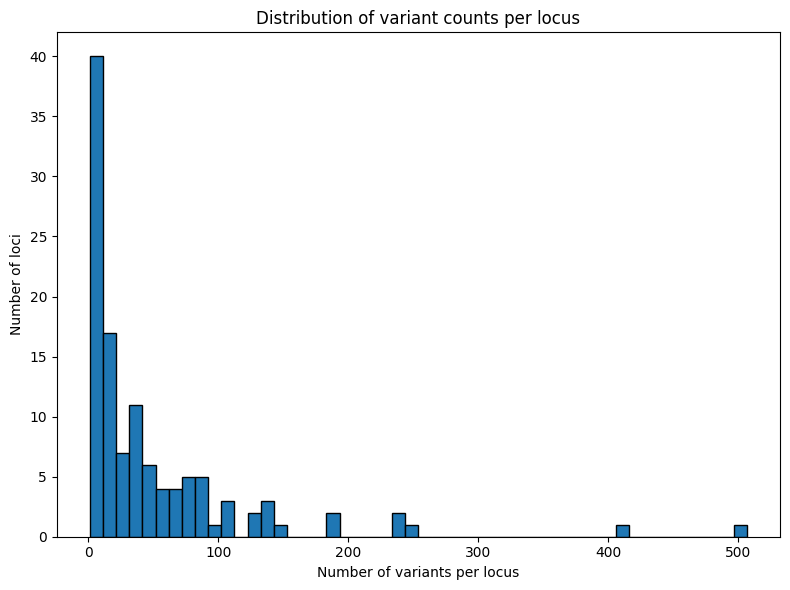

In [12]:
variant_counts = (
    merged_df.groupby('locus')[['rsID']]
    .count()
    .rename(columns={'rsID': 'variant_count'})
    .sort_values(by='variant_count')
)

# Plot histogram
plt.figure(figsize=(8,6))
plt.hist(variant_counts['variant_count'], bins=50, edgecolor='black')
plt.xlabel('Number of variants per locus')
plt.ylabel('Number of loci')
plt.title('Distribution of variant counts per locus')
plt.tight_layout()
plt.show()

In [13]:
variant_counts

,variant_count
locus,
TKT_locus0,1
MYL6_locus0,1
NEXN_locus0,1
SKI_or_C1orf86_locus0,1
LLGL2_locus0,1
...,...
ACTBL2_locus0,241
BLK_locus0,242
LMF1_locus0,247


In [14]:
len(merged_df['locus'].unique())

116

### Merge with the prioritized gene from the GWAS study

In [15]:
merged_df.to_csv("08_lead_and_LD_SNPs.csv", index=False)

### Save in a bed format

In [16]:
LD_SNP_bed_df = LD_SNP_df[["CHR_A", "BP_B", "BP_B", "SNP_A"]].copy()
LD_SNP_bed_df['CHR_A'] = "chr" + LD_SNP_bed_df['CHR_A'].astype(str)

In [17]:
LD_SNP_bed_df.to_csv("08_lead_and_LD_SNPs.bed", sep = "\t", header=False, index=False)

### Calculate the max distance between a lead SNP and another SNP with R^2>0.8

In [18]:
distances = np.abs(LD_SNP_df['BP_B'] - LD_SNP_df['BP_A'])
np.max(distances)

564943